#### This notebook is created to check different approaches for impuation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scikeras.wrappers import KerasClassifier

In [2]:
# Define a custom style with black background (matches presentation background)
grey_background_style = {
    'axes.facecolor': '#000000',  
    'figure.facecolor': '#000000',  
    'axes.edgecolor': 'white',  
    'axes.labelcolor': 'white', 
    'xtick.color': 'white', 
    'ytick.color': 'white',  
    'text.color': 'white',  
    'legend.facecolor': '#262626',  
    'legend.edgecolor': 'white'  
}

# Apply the custom style
plt.style.use(grey_background_style)

In [3]:
# read all the files
df_drop = pd.read_csv('final_drop.csv',index_col=None)
df_share = pd.read_csv('final_share.csv',index_col=None)
df_weighted = pd.read_csv('final_weighted.csv',index_col=None)
df_knn = pd.read_csv('final_knn.csv',index_col=None)

In [4]:

def evaluate_algoritms(X_train,X_test,y_train,y_test,evaluate_params,checktime=120,dont_train=[],verbose=True,scale=True):
    '''
    Arguments - 
    X_train - train features dataframe
    y_train - train target dataframe
    X_test - test features dataframe
    y_test - test target dataframe

    evaluate_params - {'model_name':hyper parameters to be used}
    checktime - If evaluation time >checktim(in s) then stop training that algorithm
    dont_train - The models in this list will not be  trained
    verbose - If true then prints accuracy score,time while execution
    scale - Tells whether to scale the data or not
    X_values - Takes the (X_train,y_train). Used when we want to pass X_train,y_train seperately instead of dataframes
    
    returns - 
    format of data - {'model_name':returned_value}
    accuracies - accuracies of all models
    trained_models - returns all trained models 
    time_taken - list of times taken by every algorithm
    predictions - list of predictions for every algorithm, useful for plotting cm
    test_values - list of (X_test,y_test) values for every algorithm, useful for plotting cm and evaluating

    '''
    from sklearn.naive_bayes import GaussianNB,MultinomialNB
    from sklearn.linear_model import LogisticRegression
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.svm import SVC 
    from sklearn.tree import DecisionTreeClassifier 
    from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler
    from sklearn.model_selection import GridSearchCV
    from sklearn.model_selection import KFold
    from sklearn.metrics import accuracy_score,top_k_accuracy_score
    from timeout_decorator import timeout, TimeoutError
    from time import time
    import tensorflow as tf

    # trained_models = dict(zip(['naive_bayes','logistic_regresion','svc','decision_tree','random_forest','adaboost','gradient_boost'],
    #                       ['','','','','','','','','']))

    trained_models = {}
    accuracies = {}
    time_taken = {}
    predictions = {}
    test_values = {}

    if type(X_train) != type(pd.DataFrame()):
        X_train = pd.DataFrame(X_train)
        X_test = pd.DataFrame(X_test)
        y_train = pd.DataFrame(y_train)
        y_test = pd.DataFrame(y_test)
    class_weights = dict(y_train.value_counts()/y_train.shape[0])



    def print_verbose(message):
        if verbose:
            print(message)


    if 'naive_bayes' not in dont_train:
        #Naive bayes
        @timeout(checktime)
        def Naive_bayes(X_train,X_test,y_train,y_test):
            
            naive_bayes = GaussianNB()
            start_time = time()
            naive_bayes.fit(X_train,y_train)
            preds = naive_bayes.predict(X_test)
            end_time = time()
            time_taken= round(end_time - start_time,2)
            acc = accuracy_score(y_test,preds)
            return acc,naive_bayes,time_taken,preds,(X_test,y_test)
        
        try:
            accuracies['naive_bayes'],trained_models['naive_bayes'],time_taken['naive_bayes'] \
                ,predictions['naive_bayes'],test_values['naive_bayes']= Naive_bayes(X_train,X_test,y_train,y_test)
            print_verbose(f'Accuracy for Naive Bayes model {accuracies["naive_bayes"]:.2f}')
            print_verbose(f"time elapsed for Naive Bayes: {time_taken['naive_bayes']}")
        except TimeoutError:
            print_verbose("Training took too long. Stopping the process for Naive Bayes.")
    
        


    if 'logistic_regression' not in dont_train:
        #Logistic Regression
        @timeout(checktime)
        def Logistic_Regression(X_train,X_test,y_train,y_test):

            if scale:

                from sklearn.preprocessing import StandardScaler
                lr_train_scaler = StandardScaler()
                lr_test_scaler = StandardScaler()
                lr_train_scaler.fit_transform(X_train)
                lr_test_scaler.fit_transform(X_test)

            params = evaluate_params['logistic_regression']

            log_regression = LogisticRegression(max_iter=params['max_iter'],solver=params['solver'],\
                                                class_weight=class_weights)
            start_time = time()
            log_regression.fit(X_train,y_train)
            preds = log_regression.predict(X_test)
            end_time = time()
            time_taken = round(end_time - start_time,2)
            acc = accuracy_score(y_test,preds)

            return acc,log_regression,time_taken,preds,(X_test,y_test)
        try:
            accuracies['logistic_regression'],trained_models['logistic_regression'],time_taken['logistic_regression'] \
                ,predictions['logistic_regression'],test_values['logistic_regression']\
                    = Logistic_Regression(X_train,X_test,y_train,y_test)
            print_verbose(f'Accuracy for Logistic Regression model {accuracies["logistic_regression"]:.2f}')
            print_verbose(f"time elapsed for Logistic Regression: {time_taken['logistic_regression']}")
        except TimeoutError:
            print_verbose("Training took too long. Stopping the process for Logistic Regression.")

    if 'KNN' not in dont_train:
        #KNN
        @timeout(checktime)
        def KNN(X_train,X_test,y_train,y_test):

            if scale:
                knn_scaler = StandardScaler()
                X_train = knn_scaler.fit_transform(X_train)
                X_test = knn_scaler.transform(X_test)

            params = evaluate_params['knn']

            knn = KNeighborsClassifier(weights=params['weighted'],n_neighbors=params['n_neighbors'])
            start_time = time()
            knn.fit(X_train,y_train)
            preds = knn.predict(X_test)
            end_time = time()
            time_taken = round(end_time - start_time,2)
            acc = accuracy_score(y_test,preds)
            return acc,knn,time_taken,preds,(X_test,y_test)
        
        try:
            accuracies['knn'],trained_models['knn'],time_taken['knn'] \
                ,predictions['knn'],test_values['knn']= KNN(X_train,X_test,y_train,y_test)
            print_verbose(f'Accuracy for KNN model {accuracies["knn"]:.2f}')
            print_verbose(f"time elapsed for KNN: {time_taken['knn']}")
        except TimeoutError:
            print_verbose("Training took too long. Stopping the process for KNN.")
        
        
    
    if 'svm' not in dont_train:
        #Svm
        @timeout(checktime)
        def Support_vector_classifier(X_train,X_test,y_train,y_test):

            if scale:
                svm_scaler = StandardScaler()
                X_train = svm_scaler.fit_transform(X_train)
                X_test = svm_scaler.transform(X_test)

            params = evaluate_params['svm']
        
            svc = SVC(kernel=params['kernel'],C=params['C'],gamma=params['gamma'],class_weight=class_weights)
            start_time = time()
            svc.fit(X_train,y_train)
            preds = svc.predict(X_test)
            end_time = time()
            time_taken = round(end_time - start_time,2)
            acc = accuracy_score(y_test,preds)
            return acc,svc,time_taken,preds,(X_test,y_test)
        
        try:
            accuracies['svm'] ,trained_models['svm'],time_taken['svm'] \
                ,predictions['svm'],test_values['svm']= Support_vector_classifier(X_train,X_test,y_train,y_test)
            print_verbose(f'Accuracy for Support vector classifier {accuracies["svm"] :.2f}')
            print_verbose(f"time elapsed for Support Vector Machine: {time_taken['svm']}")
        except TimeoutError:
            print_verbose("Training took too long. Stopping the process for SVM.")

        

    if 'decision_tree' not in dont_train:
        #Decision tree
        @timeout(checktime)
        def Decision_tree(X_train,X_test,y_train,y_test):

            params = evaluate_params['decision_tree']

#             max_depth': 10,
#  'min_samples_leaf': 2,
#  'min_samples_split': 2}

            decision_tree = DecisionTreeClassifier(random_state=42,class_weight=class_weights,\
                                                   criterion=params['criterion'],max_depth=params['max_depth'],\
                                      min_samples_split=params['min_samples_split'],min_samples_leaf=params['min_samples_leaf'])
            start_time = time()
            decision_tree.fit(X_train,y_train)
            preds = decision_tree.predict(X_test)
            end_time = time()
            time_taken = round(end_time - start_time,2)
            acc = accuracy_score(y_test,preds)
            return acc,decision_tree,time_taken,preds,(X_test,y_test)
        
        try:
            accuracies['decision_tree'],trained_models['decision_tree'],time_taken['decision_tree'] \
                ,predictions['decision_tree'],test_values['decision_tree']= Decision_tree(X_train,X_test,y_train,y_test)
            print_verbose(f'Accuracy for Decision_tree {accuracies["decision_tree"]:.2f}')
            print_verbose(f"time elapsed for Decision Tree Classifier: {time_taken['decision_tree']}")
        except TimeoutError:
            print_verbose("Traninng took too long. Stopping the process for Decision_tree")


    if 'random_forest' not in dont_train:

        #Random_forest
        @timeout(checktime)
        def Random_Forest(X_train,X_test,y_train,y_test):

            params = evaluate_params['random_forest']

            random_forest =  RandomForestClassifier(random_state=42,class_weight=class_weights,\
                                     n_estimators=params['n_estimators'],criterion=params['criterion'],max_depth=params['max_depth'],\
                                      min_samples_split=params['min_samples_split'],min_samples_leaf=params['min_samples_leaf'])
            start_time = time()
            random_forest.fit(X_train,y_train)
            preds = random_forest.predict(X_test)
            end_time = time()
            time_taken = round(end_time - start_time,2)
            acc = accuracy_score(y_test,preds)
            return acc,random_forest,time_taken,preds,(X_test,y_test)
        
        try:
            accuracies['random_forest'],trained_models['random_forest'],time_taken['random_forest'] \
                ,predictions['random_forest'],test_values['random_forest'] = Random_Forest(X_train,X_test,y_train,y_test)
            print_verbose(f'Accuracy for Random Forest {accuracies["random_forest"]:.2f}')
            print_verbose(f"time elapsed for Random Forest Classifier: {time_taken['random_forest']}")
        except TimeoutError:
            print_verbose("Training took too long. Stopping the process for Random Forest")


    
    if 'adaboost' not in dont_train:

        #Adaboost
        @timeout(checktime)
        def Adaboost(X_train,X_test,y_train,y_test):

            adaboost = AdaBoostClassifier(random_state=42,estimator=DecisionTreeClassifier())
            start_time = time()
            adaboost.fit(X_train,y_train)
            preds = adaboost.predict(X_test)
            end_time = time()
            time_taken = round(end_time - start_time,2)
            acc = accuracy_score(y_test,preds)
            return acc,adaboost,time_taken,preds,(X_test,y_test)
        
        try:
            accuracies['adaboost'],trained_models['adaboost'],time_taken['adaboost'] \
                ,predictions['adaboost'],test_values['adaboost'] = Adaboost(X_train,X_test,y_train,y_test)
            print_verbose(f'Accuracy for Adaboost {accuracies["adaboost"]:.2f}')
            print_verbose(f"time elapsed for Adaboost: {time_taken['adaboost']}")
        except TimeoutError:
            print_verbose("Training took too long. Stopping the process for Adaboost")
    

    if 'gradientboost' not in dont_train:
        #gradientboost
        @timeout(checktime)
        def Gradientboost(X_train,X_test,y_train,y_test):

            gradientboost = GradientBoostingClassifier(random_state=42)
            start_time = time()
            gradientboost.fit(X_train,y_train)
            preds = gradientboost.predict(X_test)
            end_time = time()
            time_taken = round(end_time - start_time,2)
            acc = accuracy_score(y_test,preds)
            return acc,gradientboost,time_taken,preds,(X_test,y_test)
        
        try:
            accuracies['gradientboost'],trained_models['gradientboost'],time_taken['gradientboost'] \
                ,predictions['gradientboost'],test_values['gradientboost'] = Gradientboost(X_train,X_test,y_train,y_test)
            print_verbose(f'Accuracy for Gradient Boosting {accuracies["gradientboost"]:.2f}')
            print_verbose(f"time elapsed for Gradientboost: {time_taken['gradientboost']}")
        except TimeoutError:
            print_verbose("Training took too long. Stopping the process for Gradientboosting")


    if 'ann' not in dont_train:
        #ann
        @timeout(checktime)
        def ANN(X_train,X_test,y_train,y_test):
        
            # Standardize the data
            if scale:
                ann_scaler = StandardScaler()
                X_train = ann_scaler.fit_transform(X_train)
                X_test= ann_scaler.transform(X_test)
            
            def build_model():

                # build the ANN model
                ann_model = tf.keras.models.Sequential()
                ann_model.add(tf.keras.layers.Dense(units=128, activation='relu', input_dim=X_train.shape[1]))
                ann_model.add(tf.keras.layers.Dense(units=64, activation='relu'))
                ann_model.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

                # compile the model
                ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

                return ann_model
            
            ann_model = KerasClassifier(model=build_model, epochs=10, batch_size=32, verbose=0)

            start_time = time()
            ann_model.fit(X_train, y_train,validation_data=(X_test, y_test),verbose=0)
            preds = ann_model.predict(X_test,verbose=0)
            preds = np.round(preds.squeeze(),decimals=0)
            end_time = time()
            time_taken = end_time - start_time
            acc = accuracy_score(y_test, preds)

            return acc,ann_model,time_taken,preds,(X_test,y_test)
        
        try:
            accuracies['ann'],trained_models['ann'],time_taken['ann'] \
                ,predictions['ann'],test_values['ann'] = ANN(X_train,X_test,y_train,y_test)
            print_verbose(f'Accuracy for ANN {accuracies["ann"]:.2f}')
            print_verbose(f"time elapsed for ANN: {time_taken['ann']}")
        except TimeoutError:
            print_verbose("Training took too long. Stopping the process for ANN")


    return accuracies,trained_models,time_taken,predictions,test_values



In [5]:
results = {}

In [6]:
for method,df in (zip(['drop','share','weighted','knn'],[df_drop,df_share,df_weighted,df_knn])):
    # our model is based on features excluding drop features
    drop_features = ['crime_against', 'offense_name', 'offense_category_name','ct_flag','hc_flag']
    # shuffle data 
    df = df.sample(frac=1, random_state=42)
    X = df.drop(drop_features,axis=1)
    y = df['crime_against']

    evaluate_params = {'logistic_regression':{'solver':'lbfgs','max_iter':1000},
                    'knn':{'n_neighbors': 8, 'p': 1, 'weighted': 'distance'},
                    'svm':{'kernel':'rbf','C':5,'gamma':'auto'},
                    'decision_tree':{'criterion': 'gini','max_depth': 8,'min_samples_leaf': 1,'min_samples_split': 4},
                    'random_forest':{'criterion': 'gini','max_depth': 12,'min_samples_leaf': 1,\
                                        'min_samples_split': 2,'n_estimators': 200}}

    X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

    accuracies,trained_models,time_taken,predictions,test_values \
    = evaluate_algoritms(X_train,X_test,y_train,y_test,evaluate_params,checktime=120,dont_train=['ann'],scale=True)

    results[method] = accuracies




Accuracy for Naive Bayes model 0.68
time elapsed for Naive Bayes: 0.01
Accuracy for Logistic Regression model 0.69
time elapsed for Logistic Regression: 0.58
Accuracy for KNN model 0.72
time elapsed for KNN: 1.21
Accuracy for Support vector classifier 0.71
time elapsed for Support Vector Machine: 27.54
Accuracy for Decision_tree 0.73
time elapsed for Decision Tree Classifier: 0.1
Accuracy for Random Forest 0.75
time elapsed for Random Forest Classifier: 4.33
Accuracy for Adaboost 0.68
time elapsed for Adaboost: 0.21
Accuracy for Gradient Boosting 0.76
time elapsed for Gradientboost: 3.76
Accuracy for Naive Bayes model 0.67
time elapsed for Naive Bayes: 0.01
Accuracy for Logistic Regression model 0.67
time elapsed for Logistic Regression: 0.51
Accuracy for KNN model 0.71
time elapsed for KNN: 1.29
Accuracy for Support vector classifier 0.70
time elapsed for Support Vector Machine: 33.75
Accuracy for Decision_tree 0.71
time elapsed for Decision Tree Classifier: 0.1
Accuracy for Random Fo

In [7]:
results

{'drop': {'naive_bayes': 0.6820424272323631,
  'logistic_regression': 0.6898125308337445,
  'knn': 0.7222496299950666,
  'svm': 0.7121361618154909,
  'decision_tree': 0.7322397631968426,
  'random_forest': 0.7507400098667982,
  'adaboost': 0.683769116921559,
  'gradientboost': 0.7606068080907745},
 'share': {'naive_bayes': 0.6743886743886743,
  'logistic_regression': 0.6741546741546741,
  'knn': 0.7124137124137124,
  'svm': 0.6970866970866971,
  'decision_tree': 0.7052767052767053,
  'random_forest': 0.7282087282087282,
  'adaboost': 0.6704106704106704,
  'gradientboost': 0.7539487539487539},
 'weighted': {'naive_bayes': 0.6773969430291802,
  'logistic_regression': 0.6813339509031959,
  'knn': 0.7189671144048171,
  'svm': 0.701829550717925,
  'decision_tree': 0.7072718851320056,
  'random_forest': 0.7300833719314498,
  'adaboost': 0.6748494673459935,
  'gradientboost': 0.7561371005094951},
 'knn': {'naive_bayes': 0.6801026016855991,
  'logistic_regression': 0.6814461951874924,
  'knn':

Text(0.5, 1.05, 'Impuation using different approaches')

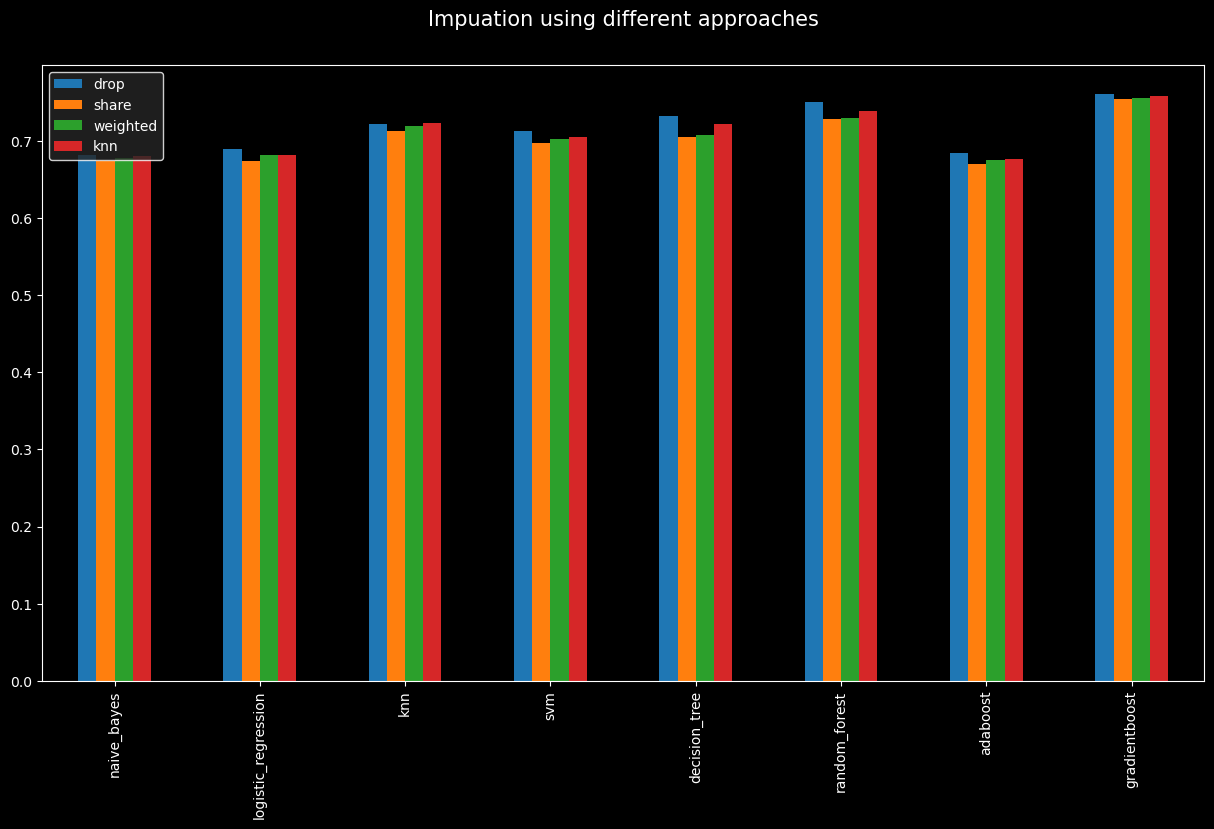

In [8]:
df = pd.DataFrame(results)
ax = df.plot(kind='bar',figsize=(15,8))
ax.set_title('Impuation using different approaches',fontsize=15,color='white',y=1.05)

In [9]:
df_drop.shape

(40536, 19)